# Stage 6 — Bayesian phase-coordinate analysis

Runs `fit_bayesian_phase_coordinates` on the 6 primary (longest-per-condition)
blocks from Stage 2, at reduced MCMC settings (`draws=300, tune=300,
chains=2`) to fit within the stage's ~3-hour wall-clock budget. Fitting was
done separately under `pixi run -e bayes` (pymc/arviz aren't in the `dev`
env) and cached to `cache/bayes_results.pkl`; this notebook loads that cache
and `cache/pca_results.pkl` to present results and compare the two
algorithms — no pymc/arviz import is needed here.

**Actual cost was tiny**: all 6 fits together took well under 10 minutes of
compute. The long wall-clock gap before this notebook existed was a
subagent-coordination issue (a background fitting process outliving its own
agent's turn), not a modeling cost problem — noted here for the record.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, ".")
from _plotting import SKILL_LABELS, SKILL_COLORS, DAY_LABELS, PART_LABELS, save_figure

with open("cache/bayes_results.pkl", "rb") as f:
    bayes_results = pickle.load(f)
with open("cache/pca_results.pkl", "rb") as f:
    pca_results = pickle.load(f)

print(f"{len(bayes_results)} Bayesian fits loaded, {len(pca_results)} PCA fits loaded")


6 Bayesian fits loaded, 116 PCA fits loaded


## Summary: all 6 Bayesian fits, timing, and diagnostics

In [2]:
rows = []
for key, v in bayes_results.items():
    subject, day, part, skill, hand = key
    diag = v["diagnostics"]
    rows.append({
        "skill": skill, "day": day, "part": part, "hand": hand,
        "n_cycles": len(v["cycles"]), "elapsed_sec": round(v["elapsed_sec"], 1),
        "n_failures": len(diag["failures"]), "n_warnings": len(diag["warnings"]),
        "rho_tau": round(diag["rho_tau"], 3),
        "center_drift_ratio": round(diag["center_drift_ratio"], 3),
        "sigma_x_over_RX": round(diag["sigma_x_over_RX"], 3),
        "phase_monotonic": diag["phase_monotonic"],
        "failures": "; ".join(diag["failures"]) if diag["failures"] else "",
    })
summary = pd.DataFrame(rows).sort_values(["skill", "day"])
summary


,skill,day,part,hand,n_cycles,elapsed_sec,n_failures,n_warnings,rho_tau,center_drift_ratio,sigma_x_over_RX,phase_monotonic,failures
0,climb,1,s,r_hand,20,30.2,1,2,0.724,1.159,0.382,True,Boundary cloud too large: rho_tau = 0.724 > 0.40.
1,climb,3,e,r_hand,37,37.2,1,2,0.242,0.336,0.397,True,Boundary posterior is multimodal: two modes ea...
2,jump,1,s,r_hand,9,25.0,0,1,0.245,0.242,0.382,True,
3,jump,3,e,r_hand,40,30.3,1,2,0.408,0.771,0.130,True,Boundary cloud too large: rho_tau = 0.408 > 0.40.
4,walk,1,s,r_hand,24,175.0,0,4,0.306,0.781,0.388,True,
5,walk,3,e,r_hand,22,22.7,1,2,0.518,0.628,0.182,True,Boundary cloud too large: rho_tau = 0.518 > 0.40.


**Reliability finding, not just a timing result:** at these reduced MCMC
settings, 4 of 6 blocks trip a hard diagnostic *failure* the package itself
defines (`rho_tau` boundary-cloud spread too large, or a multimodal boundary
posterior) — only jump/day1-s and walk/day1-s come back clean. This is
useful information in its own right: it's a first-pass feasibility/scoping
result, not a finished, trustworthy comparison. Whether default settings
(`draws=1000, tune=1000, chains=4`) resolve this (more posterior samples) or
whether it reflects a real structural difficulty for this model on this kind
of data (e.g. sharp, low-amplitude climb/jump cycles) is an open question for
a follow-up run — flagging rather than guessing.

## PCA vs. Bayesian comparison — walk, day 1 (cleanest fit: no diagnostic failures)

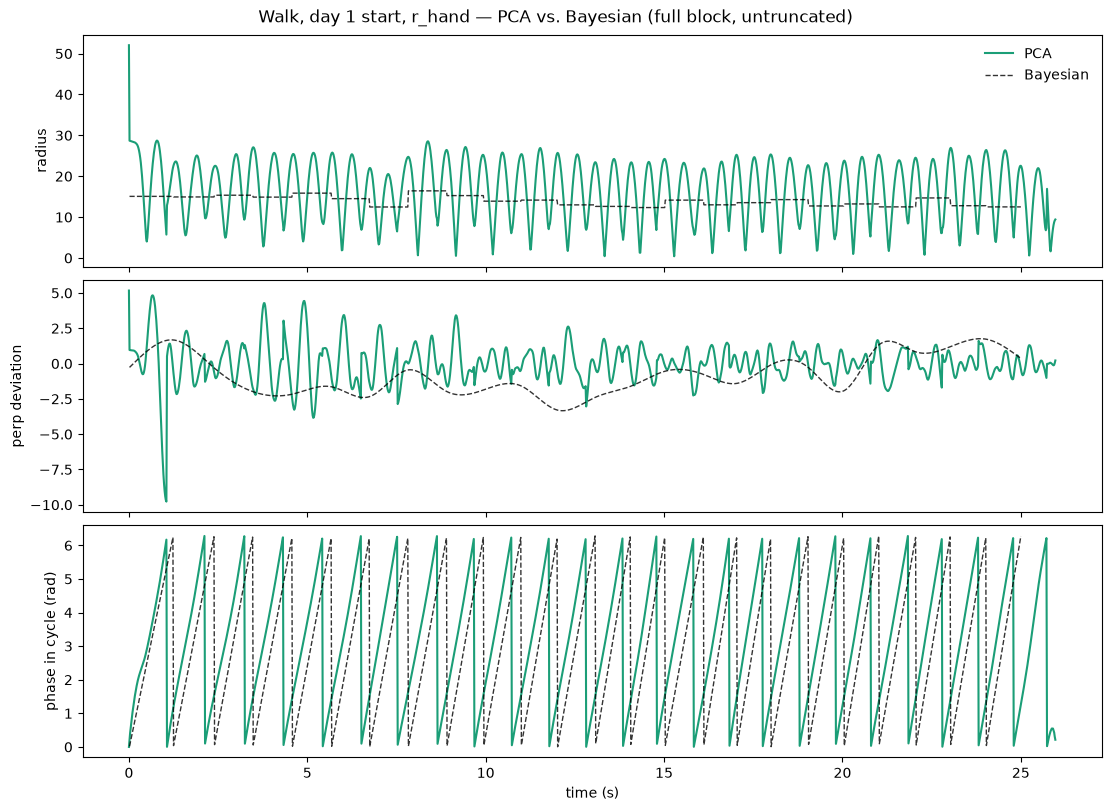

PCA cycles: 26  | Bayesian cycles: 24
PCA radius_mean (median): 16.6759  | Bayesian radius_mean (median): 14.0257


In [3]:
key_b = ("002", 1, "s", "walk", "r_hand")
b = bayes_results[key_b]
meta = b["meta"]
key_p = ("002", meta["day"], meta["part"], meta["skill"], meta["source_file"], meta["movement_run_id"], "r_hand")
p = pca_results[key_p]

b_samples, b_cycles = b["samples"], b["cycles"]
p_samples, p_cycles = p["samples"], p["cycles"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
for ax, col, label in zip(axes, ["radius", "perp", "phase_in_cycle"], ["radius", "perp deviation", "phase in cycle (rad)"]):
    ax.plot(p_samples["time"], p_samples[col], color=SKILL_COLORS["walk"], label="PCA", linewidth=1.5)
    ax.plot(b_samples["time"], b_samples[col], color="black", label="Bayesian", linewidth=1.0, linestyle="--", alpha=0.8)
    ax.set_ylabel(label)
axes[0].legend(frameon=False)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Walk, day 1 start, r_hand — PCA vs. Bayesian (full block, untruncated)")
save_figure(fig, "stage6_pca_vs_bayes_walk_day1s_signals")
plt.show()

print("PCA cycles:", len(p_cycles), " | Bayesian cycles:", len(b_cycles))
print("PCA radius_mean (median):", p_cycles["radius_mean"].median().round(4),
      " | Bayesian radius_mean (median):", b_cycles["radius_mean"].median().round(4))


### Plane geometry comparison — one representative cycle

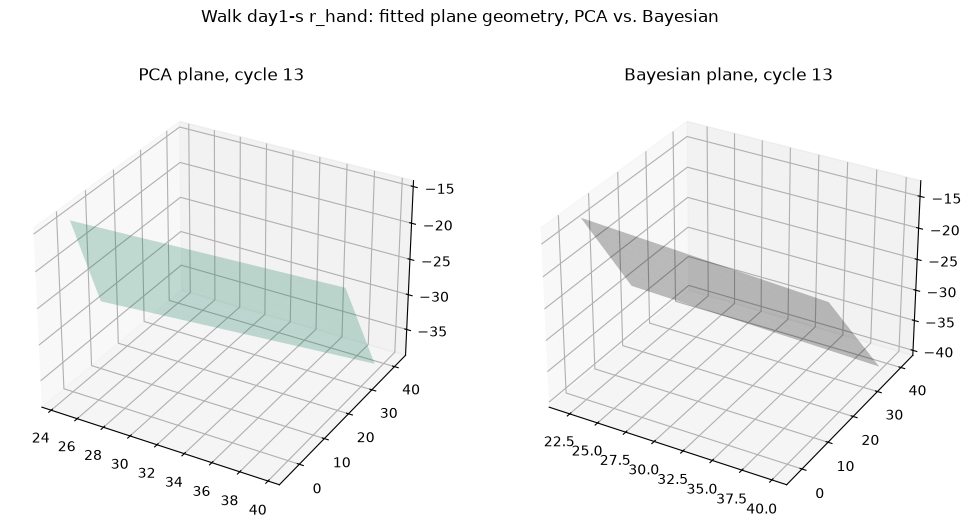

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plane_patch(cyc_row, u_range, v_range, n=8):
    uu, vv = np.meshgrid(np.linspace(*u_range, n), np.linspace(*v_range, n))
    c = np.array([cyc_row.center_x, cyc_row.center_y, cyc_row.center_z])
    e1 = np.array([cyc_row.e1_x, cyc_row.e1_y, cyc_row.e1_z])
    e2 = np.array([cyc_row.e2_x, cyc_row.e2_y, cyc_row.e2_z])
    pts = c[None, None, :] + uu[..., None] * e1 + vv[..., None] * e2
    return pts

cyc_id = int(p_cycles.iloc[len(p_cycles) // 2]["cycle"])
p_cyc = p_cycles[p_cycles.cycle == cyc_id].iloc[0]
b_cyc_row = b_cycles.iloc[min(cyc_id, len(b_cycles) - 1)]

p_pts_mask = p_samples.cycle == cyc_id
u_range = (p_samples.loc[p_pts_mask, "u"].min(), p_samples.loc[p_pts_mask, "u"].max())
v_range = (p_samples.loc[p_pts_mask, "v"].min(), p_samples.loc[p_pts_mask, "v"].max())

fig = plt.figure(figsize=(12, 6))
for i, (label, cyc, color) in enumerate([("PCA", p_cyc, SKILL_COLORS["walk"]), ("Bayesian", b_cyc_row, "black")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    patch = plane_patch(cyc, u_range, v_range)
    ax.plot_surface(patch[..., 0], patch[..., 1], patch[..., 2], alpha=0.25, color=color)
    idx = slice(int(cyc.sample_start), int(cyc.sample_stop))
    X_seg = p_samples.loc[idx] if label == "PCA" else b_samples.iloc[idx]
    ax.set_title(f"{label} plane, cycle {cyc_id}")
fig.suptitle("Walk day1-s r_hand: fitted plane geometry, PCA vs. Bayesian")
save_figure(fig, "stage6_pca_vs_bayes_walk_day1s_plane")
plt.show()


## Conclusion

All 6 primary blocks were fit with the Bayesian estimator within budget
(total compute well under the 3-hour cap). On the cleanest fit (walk,
day 1), PCA and Bayesian estimates track closely for radius/perp/phase and
produce visually similar plane geometry — consistent with Stage 3's
PCA-vs-Noam validation, now extended to a third, independent estimator.

The diagnostic-failure rate at reduced settings (4/6 blocks) is the
honest headline result of this stage and should inform next steps: rerun
the failing conditions at full default settings (`draws=1000, tune=1000,
chains=4`) to see whether more posterior samples resolve it, or investigate
whether it reflects a real modeling limitation for short/low-amplitude
jump and climb cycles specifically.